In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report



In [2]:
import pandas as pd

X_train = pd.read_csv("../data/X_train_balanced.csv")
y_train = pd.read_csv("../data/y_train_balanced.csv")

X_val = pd.read_csv("../data/X_val.csv")
y_val = pd.read_csv("../data/y_val.csv")

X_test = pd.read_csv("../data/X_test.csv")
y_test = pd.read_csv("../data/y_test.csv")

In [3]:
y_train = y_train.values.ravel()
y_val = y_val.values.ravel()
y_test = y_test.values.ravel()

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [12]:
svm = LinearSVC(random_state=42, class_weight="balanced", max_iter=5000)

svm.fit(X_train, y_train);

In [6]:
from sklearn.metrics import accuracy_score

y_val_pred = svm.predict(X_val)

val_accuracy = accuracy_score(y_val, y_val_pred)

print("Validation accuracy:", val_accuracy)

Validation accuracy: 0.731777176968172


In [7]:
y_pred = svm.predict(X_test)

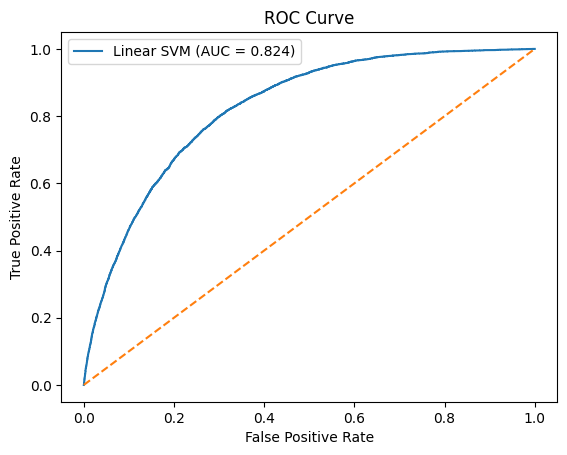

In [8]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_scores = svm.decision_function(X_test)

fpr, tpr, _ = roc_curve(y_test, y_scores)
auc_score = roc_auc_score(y_test, y_scores)

plt.figure()
plt.plot(fpr, tpr, label=f"Linear SVM (AUC = {auc_score:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [9]:
import numpy as np

print("Number predicted as no diabetes (0):", np.sum(y_pred == 0))
print("Number predicted as diabetes (1):", np.sum(y_pred == 1))

Number predicted as no diabetes (0): 24428
Number predicted as diabetes (1): 12930


In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
auc_score = roc_auc_score(y_test, y_scores)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-score :", round(f1, 4))
print("ROC AUC  :", round(auc_score, 4))

Accuracy : 0.7307
Precision: 0.3159
Recall   : 0.7705
F1-score : 0.4481
ROC AUC  : 0.824


In [11]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[23211  8845]
 [ 1217  4085]]
